In [1]:
import pandas as pd
import numpy as np

# Create synthetic dataset
np.random.seed(42)

n = 500
heights = np.random.normal(loc=170, scale=10, size=n)  # cm
weights = heights * 0.4 + np.random.normal(loc=0, scale=5, size=n)  # kg

df = pd.DataFrame({
    "Height": heights,
    "Weight": weights
})

df.to_csv("weight-height.csv", index=False)

df.head()

,Height,Weight
0,174.967142,74.617744
1,168.617357,76.994026
2,176.476885,63.597916
3,185.230299,76.906966
4,167.658466,63.810174


In [2]:
import pandas as pd

df = pd.read_csv("weight-height.csv")

print(df.head())
print(df.describe())

       Height     Weight
0  174.967142  74.617744
1  168.617357  76.994026
2  176.476885  63.597916
3  185.230299  76.906966
4  167.658466  63.810174
           Height      Weight
count  500.000000  500.000000
mean   170.068380   68.186483
std      9.812532    6.034315
min    137.587327   49.567764
25%    162.996926   64.444735
50%    170.127971   68.043732
75%    176.367833   71.677705
max    208.527315   91.893208


In [3]:
from sklearn.model_selection import train_test_split

X = df[["Height"]]   # Feature
y = df["Weight"]     # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
print("Decision Tree MSE:", mse_dt)

Decision Tree MSE: 30.3726918787086


In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Random Forest MSE:", mse_rf)

Random Forest MSE: 30.454626709392134


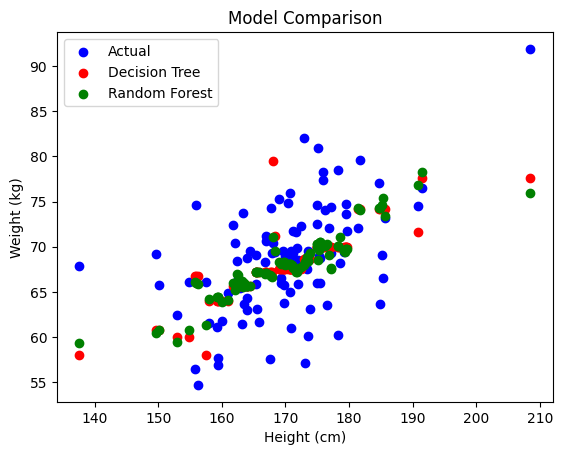

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.scatter(X_test, y_pred_dt, color="red", label="Decision Tree")
plt.scatter(X_test, y_pred_rf, color="green", label="Random Forest")

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [7]:
importances = rf_model.feature_importances_
print("Feature Importance:", importances)

Feature Importance: [1.]
